# Homework 1: PCA

Problem 1 - Principal Component Analysis
---

In this problem you'll be implementing Dimensionality reduction using Principal Component Analysis technique. 

The gist of PCA Algorithm to compute principal components is follows:
- Calculate the covariance matrix X of data points.
- Calculate eigenvectors and corresponding eigenvalues.
- Sort the eigenvectors according to their eigenvalues in decreasing order.
- Choose first k eigenvectors which satisfies target explained variance.
- Transform the original data of shape m observations times n features into m observations times k selected features.


The skeleton for the *PCA* class is below. Scroll down to find more information about your tasks.

In [2]:
import math
import pickle
import gzip
import numpy as np
import pandas
import matplotlib.pylab as plt
%matplotlib inline

In [89]:
#from sklearn.preprocessing import StandardScaler
#X = np.array([[1,2,3], [4,15,16]])
#X = StandardScaler().fit_transform(X)
#m = X.mean(axis=0)
#X = X - m
#print(X, X.mean(axis=0), X.var(axis=0))
#print(m, X - m)
#C = (X - m).T@(X - m)
#print(np.linalg.eig(C))

In [132]:
class PCA:
    def __init__(self, target_explained_variance=None):
        """
        explained_variance: float, the target level of explained variance
        """
        self.target_explained_variance = target_explained_variance
        self.feature_size = -1

    def standardize(self, X):
        """
        standardize features using standard scaler
        :param X: input data with shape m (# of observations) X n (# of features)
        :return: standardized features (Hint: use skleanr's StandardScaler. Import any library as needed)
        """
        # your code here
        from sklearn.preprocessing import StandardScaler
        return StandardScaler().fit_transform(X)

    def compute_mean_vector(self, X_std):
        """
        compute mean vector
        :param X_std: transformed data
        :return n X 1 matrix: mean vector
        """
        # your code here
        return X_std.mean(axis=0)

    def compute_cov(self, X_std, mean_vec):
        """
        Covariance using mean, (don't use any numpy.cov)
        :param X_std:
        :param mean_vec:
        :return n X n matrix:: covariance matrix
        """
        # your code here
        return (X_std - mean_vec).T@(X_std - mean_vec) / (X_std.shape[0] - 1)
        

    def compute_eigen_vector(self, cov_mat):
        """
        Eigenvector and eigen values using numpy. Uses numpy's eigenvalue function
        :param cov_mat:
        :return: (eigen_values, eigen_vector)
        """
        # your code here
        return np.linalg.eig(cov_mat)
        

    def compute_explained_variance(self, eigen_vals):
        """
        sort eigen values and compute explained variance.
        explained variance informs the amount of information (variance)
        can be attributed to each of  the principal components.
        :param eigen_vals:
        :return: explained variance.
        """
        # your code here
        #return sorted(eigen_vals**2, reverse=True) / np.sum(eigen_vals**2)
        return sorted(eigen_vals, reverse=True) / np.sum(eigen_vals)
        

    def cumulative_sum(self, var_exp):
        """
        return cumulative sum of explained variance.
        :param var_exp: explained variance
        :return: cumulative explained variance
        """
        return np.cumsum(var_exp)
    
    def compute_weight_matrix(self, eig_pairs, cum_var_exp):
        """
        compute weight matrix of top principal components conditioned on target
        explained variance.
        (Hint : use cumilative explained variance and target_explained_variance to find
        top components)
        
        :param eig_pairs: list of tuples containing eigenvalues and eigenvectors, 
        sorted by eigenvalues in descending order (the biggest eigenvalue and corresponding eigenvectors first).
        :param cum_var_exp: cumulative expalined variance by features
        :return: weight matrix (the shape of the weight matrix is n X k)
        """
        # your code here
        var, i = 0, 0
        mat = []
        while cum_var_exp[i] < self.target_explained_variance:
            mat.append(eig_pairs[i][1].tolist())
            i += 1
        return np.array(mat).T
    
        #matrix_w = np.ones((self.feature_size, 1))
        #for i in range(len(eig_pairs)):
        #     if cum_var_exp[i] < self.target_explained_variance:
        #         matrix_w = np.hstack((matrix_w,
        #                               eig_pairs[i][1].reshape(self.feature_size,
        #                                                       1)))
        #return np.delete(matrix_w, [0], axis=1).tolist()

    def plot_vars(self, cum_var_exp, k):
        import matplotlib.pylab as plt
        plt.figure(figsize=(10,6))
        plt.plot(range(1, len(cum_var_exp)+1), cum_var_exp, 'b.-')
        plt.xlabel('# (dominant) principal components', size=20)
        plt.ylabel('(total) variance explained', size=20)
        plt.axhline(y=self.target_explained_variance, color='green', linestyle='dashed',
                    label=f'target expl. var: {self.target_explained_variance}')
        plt.axvline(x=k, color='red', linestyle='dashed', label=f'#PC: {k}')
        plt.grid()
        plt.title('PC vs. variance', size=25)
        plt.legend(prop = {'size' : 15})
        plt.show()

    def transform_data(self, X_std, matrix_w):
        """
        transform data to subspace using weight matrix
        :param X_std: standardized data
        :param matrix_w: weight matrix
        :return: data in the subspace
        """
        return X_std.dot(matrix_w)
    
    def plot_reconstructed(self, X, X_proj, matrix_w):
        import matplotlib.pylab as plt
        n = 5
        indices = np.random.choice(len(X), 5)
        plt.figure(figsize=(15,8))
        plt.gray()
        for i in range(n):
            plt.subplot(2,n,i+1), plt.imshow(np.reshape(X[indices[i]], (28,28)))
            plt.axis('off'), plt.title('original', size=20)
            plt.subplot(2,n,i+1+n), plt.imshow(np.reshape(X_proj[indices[i]]@matrix_w.T, (28,28)))
            plt.axis('off'), plt.title('reconstruction', size=20)
        plt.suptitle(f'Original vs. PCA reconstruction with {matrix_w.shape[1]} PCs', size=25)
        plt.tight_layout()
        plt.show()

    def fit(self, X):
        """    
        entry point to the transform data to k dimensions
        standardize and compute weight matrix to transform data.
        The fit functioin returns the transformed features. k is the number of features which cumulative 
        explained variance ratio meets the target_explained_variance.
        :param   m X n dimension: train samples
        :return  m X k dimension: subspace data. 
        """
    
        self.feature_size = X.shape[1]
        
        # your code here
        X_std = self.standardize(X)
        m = self.compute_mean_vector(X_std)
        #print(X.shape) #, X.mean(axis=0), X.var(axis=0))
        cov = self.compute_cov(X_std, m)
        #print(X.shape, cov.shape)
        vals, vecs = self.compute_eigen_vector(cov)
        eig_pairs = [(vals[i], vecs[:,i]) for i in range(len(vals))]
        eig_pairs.sort()
        eig_pairs.reverse()
        #print(vals.shape, vecs.shape)
        exp_vars = self.compute_explained_variance(vals)
        #print(len(exp_vars))
        cum_var_exp = self.cumulative_sum(exp_vars)
        #print(cum_var_exp.shape)
        matrix_w = self.compute_weight_matrix(eig_pairs, cum_var_exp)      
        self.plot_vars(cum_var_exp, matrix_w.shape[1])
        #print(matrix_w.shape)
        X_proj = self.transform_data(X_std=X_std, matrix_w=matrix_w)
        self.plot_reconstructed(X, X_proj, matrix_w)
        return X_proj


**[ PART A ]** Your task involves implementing helper functions to compute *mean, covariance, eigenvector and weights*.

complete `fit()` to using all helper functions to find reduced dimension data.

Run PCA on *fashion mnist dataset* to reduce the dimension of the data.

fashion mnist data consists of samples with *784 dimensions*.

Report the reduced dimension $k$ for target explained variance of **0.99**

In [133]:
X_train = pickle.load(open('./data/fashionmnist/train_images.pkl','rb'))
y_train = pickle.load(open('./data/fashionmnist/train_image_labels.pkl','rb'))

X_train = X_train[:1500]
y_train = y_train[:1500]

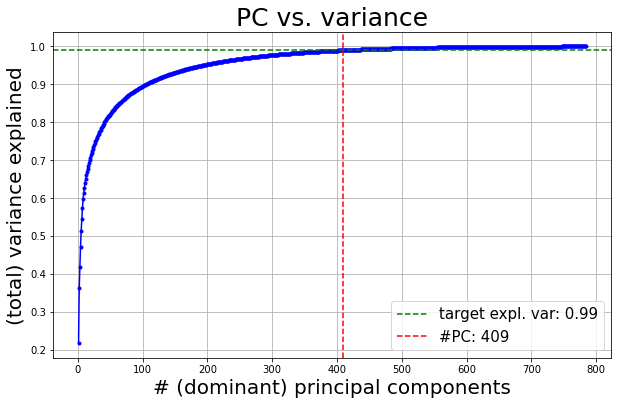

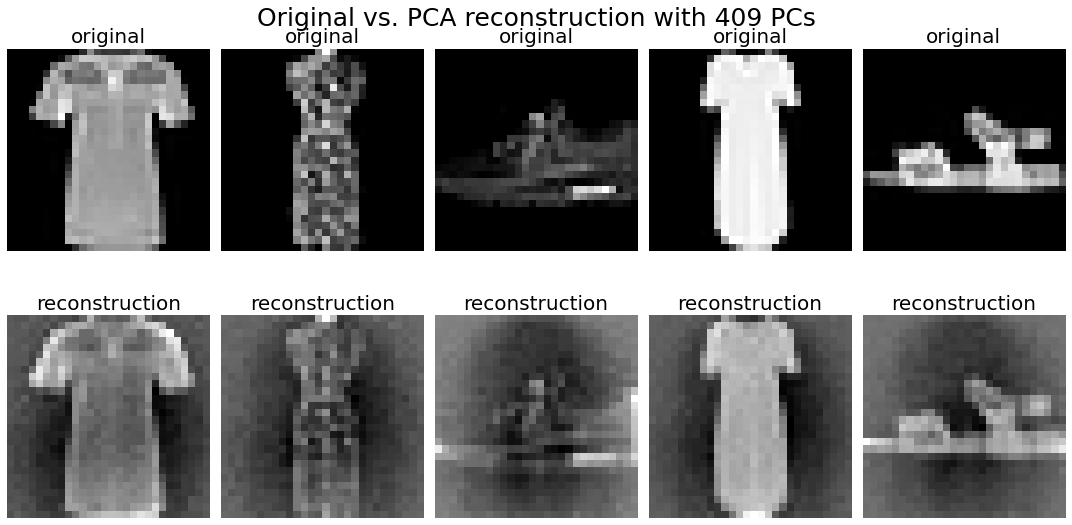

In [134]:
pca_handler = PCA(target_explained_variance=0.99)
X_train_updated = pca_handler.fit(X_train)